# Final Project Draft
This notebook implements the draft: data loading, exploratory analysis, 2-3 engineered features, two ML models, comparison, and next steps.

Notes: If `data/dataset.csv` is empty or not provided, this notebook will generate a synthetic demo dataset so you can run the pipeline end-to-end. Replace `data/dataset.csv` with your chosen dataset to run with your data.

In [13]:
# Imports
import os
import time
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.datasets import make_classification

In [14]:
# Load dataset (uses data/dataset.csv if present, otherwise generates a synthetic demo dataset)
data_path = 'data/dataset.csv'
df = None
if os.path.exists(data_path) and os.path.getsize(data_path) > 10:
    df = pd.read_csv(data_path)
    print('Loaded dataset from', data_path)
else:
    print('data/dataset.csv not found or empty — generating synthetic demo dataset')
    X, y = make_classification(n_samples=1000, n_features=10, n_informative=3, n_redundant=2, random_state=42)
    cols = [f'feat_{i}' for i in range(X.shape[1])]
    df = pd.DataFrame(X, columns=cols)
    df['target'] = y
    # introduce some missing values for demonstration
# Attempt to load local dataset first (data/dataset.csv). If empty, try downloading FBref Premier League seasons; otherwise fall back to synthetic demo.
data_path = 'data/dataset.csv'
df = None
if os.path.exists(data_path) and os.path.getsize(data_path) > 10:
    df = pd.read_csv(data_path)
    print('Loaded dataset from', data_path)
else:
    print('data/dataset.csv not found or empty — attempting to download FBref Premier League player-season tables (2019-20 through 2024-25)')
    import requests, re
    from bs4 import BeautifulSoup
    base_comp_url = 'https://fbref.com/en/comps/9/Premier-League-Stats'
    seasons_to_get = ['2019-2020','2020-2021','2021-2022','2022-2023','2023-2024','2024-2025']
    season_links = []
    try:
        r = requests.get(base_comp_url, headers={'User-Agent':'Mozilla/5.0'})
        soup = BeautifulSoup(r.text, 'html.parser')
        for a in soup.find_all('a', href=True):
            href = a['href']
            txt = a.get_text()
            if '/en/comps/9/' in href and any(s in href for s in seasons_to_get):
                full = 'https://fbref.com' + href
                if full not in season_links:
                    season_links.append(full)
    except Exception as e:
        print('Could not fetch competition page:', e)
        season_links = []
    # helper to extract tables even when wrapped in HTML comments
    def read_tables_from_url(url):
        try:
            rr = requests.get(url, headers={'User-Agent':'Mozilla/5.0'})
            html = re.sub('<!--|-->', '', rr.text)
            tables = pd.read_html(html)
            return tables
        except Exception as e:
            print('Failed to read tables from', url, e)
            return []
    frames = []
    for url in season_links:
        print('Processing season page:', url)
        tables = read_tables_from_url(url)
        for t in tables:
            if 'Player' in t.columns:
                t['season_page'] = url
                frames.append(t)
    if len(frames) > 0:
        df = pd.concat(frames, ignore_index=True, sort=False)
        # normalize column names and save a copy
        df.columns = [c.strip() for c in df.columns]
        os.makedirs('data', exist_ok=True)
        df.to_csv('data/fbref_premier_players.csv', index=False)
        print('Downloaded and saved fbref_premier_players.csv with', df.shape[0], 'rows')
    else:
        print('FBref download failed or no player tables found; falling back to synthetic demo')
        X, y = make_classification(n_samples=1000, n_features=10, n_informative=3, n_redundant=2, random_state=42)
        cols = [f'feat_{i}' for i in range(X.shape[1])]
        df = pd.DataFrame(X, columns=cols)
        df['target'] = y
        rng = np.random.default_rng(42)
        mask = rng.choice([True, False], size=df.shape, p=[0.02, 0.98])
        df = df.mask(mask)

# Create is_tottenham flag from common club columns if present
if df is not None:
    if 'squad' in df.columns.str.lower() or 'team' in df.columns.str.lower() or 'club' in df.columns.str.lower():
        # try common names (case-insensitive)
        col_candidates = [c for c in df.columns if c.lower() in ['squad','team','club']]
        if len(col_candidates) > 0:
            team_col = col_candidates[0]
            df['is_tottenham'] = df[team_col].astype(str).str.contains('Tottenham', case=False, na=False).astype(int)
            print('Created is_tottenham from', team_col)
    else:
        # some FBref tables use 'Squad' or 'Team' capitalization; try a case-insensitive check
        possible = [c for c in df.columns if 'tottenham' in str(df[c].dropna().astype(str).str.lower().unique()).lower()]
        if len(possible) == 0:
            # no explicit team column found
            pass

df.head()
id


UnicodeDecodeError: 'utf-8' codec can't decode byte 0x9c in position 67: invalid start byte

In [ ]:
# Basic statistics and missing value analysis
print('Shape:', df.shape)
display(df.dtypes)
print('Missing values (count):')
display(df.isnull().sum())
if 'target' in df.columns:
    print('Target distribution:')
    display(df['target'].value_counts(dropna=False))

Shape: (1000, 11)


feat_0    float64
feat_1    float64
feat_2    float64
feat_3    float64
feat_4    float64
feat_5    float64
feat_6    float64
feat_7    float64
feat_8    float64
feat_9    float64
target    float64
dtype: object

Missing values (count):


feat_0    15
feat_1    18
feat_2    24
feat_3    15
feat_4    24
feat_5    15
feat_6    26
feat_7    20
feat_8    19
feat_9    18
target    17
dtype: int64

Target distribution:


target
1.0    496
0.0    487
NaN     17
Name: count, dtype: int64

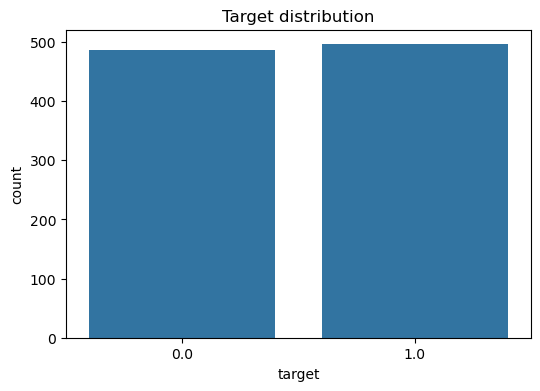

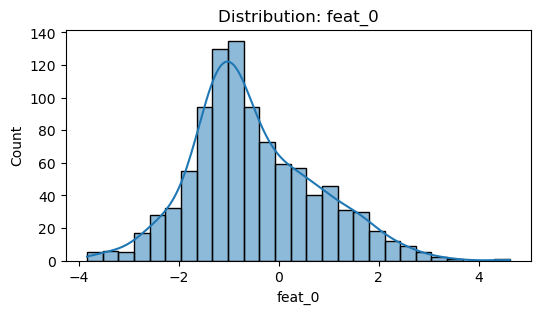

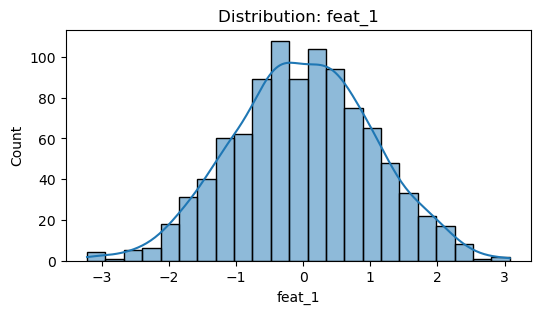

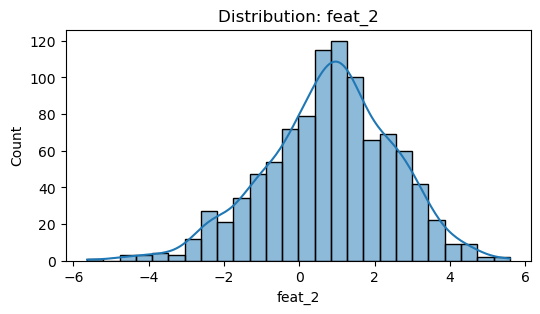

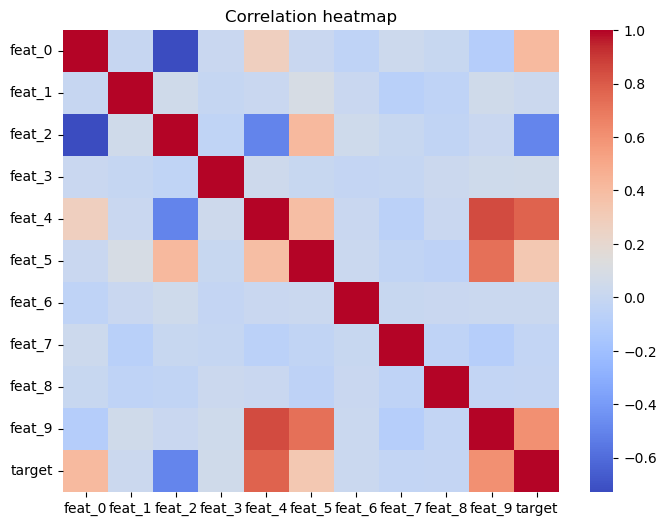

In [ ]:
# Visualizations: target distribution and feature relationships
%matplotlib inline
plt.figure(figsize=(6,4))
if 'target' in df.columns:
    sns.countplot(x='target', data=df)
    plt.title('Target distribution')
    plt.show()

# Feature distribution for first two features
feat_cols = [c for c in df.columns if c != 'target'][:3]
for c in feat_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df[c].dropna(), kde=True)
    plt.title(f'Distribution: {c}')
    plt.show()

# Correlation heatmap (numeric only)
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=False, cmap='coolwarm')
plt.title('Correlation heatmap')
plt.show()

**Quick summary of key data characteristics (2-3 sentences):**

- Describe class balance, missing data, and notable feature correlations that will influence modeling choices.
- If using your own dataset, replace `data/dataset.csv` and rerun the notebook.

## Feature engineering (2-3 features)

Cluster counts:


cluster
3    294
1    199
4    192
2    161
0    154
Name: count, dtype: int64

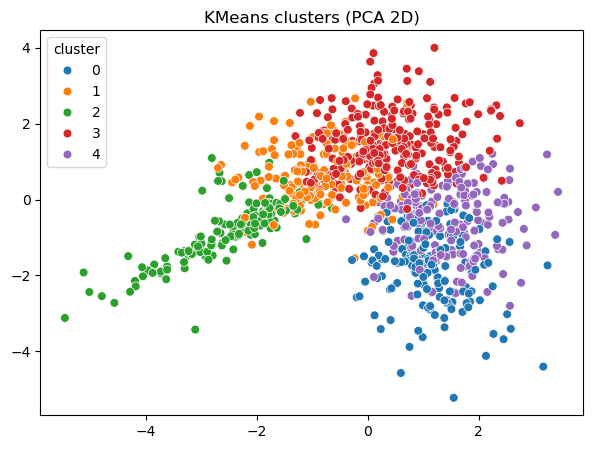

In [ ]:
# Clustering to define player archetypes (K-Means)
num_cols_all = df.select_dtypes(include=[np.number]).columns.tolist()
# drop target columns from clustering features if present
for tcol in ['target','is_tottenham']:
    if tcol in num_cols_all:
        num_cols_all.remove(tcol)
if len(num_cols_all) >= 3:
    X_cluster = df[num_cols_all].copy()
    X_cluster = X_cluster.fillna(X_cluster.median())
    X_scaled = StandardScaler().fit_transform(X_cluster)
    kmeans = KMeans(n_clusters=5, random_state=42)
    clusters = kmeans.fit_predict(X_scaled)
    df['cluster'] = clusters
    print('Cluster counts:')
    display(df['cluster'].value_counts())
    # PCA for 2D visualization
    pca = PCA(n_components=2, random_state=42)
    pcs = pca.fit_transform(X_scaled)
    plt.figure(figsize=(7,5))
    sns.scatterplot(x=pcs[:,0], y=pcs[:,1], hue=df['cluster'], palette='tab10', legend='full', s=40)
    plt.title('KMeans clusters (PCA 2D)')
    plt.show()
    # If we have Tottenham labels, show cluster distribution among Tottenham players
    if 'is_tottenham' in df.columns:
        print('Tottenham players per cluster:')
        display(df[df['is_tottenham']==1]['cluster'].value_counts())
else:
    print('Not enough numeric features for clustering (need >=3).')

In [ ]:
# Create engineered features
df_fe = df.copy()
num_cols = df_fe.select_dtypes(include=[np.number]).columns.drop('target', errors='ignore')
# Feature 1: interaction between first two numeric features
if len(num_cols) >= 2:
    c0, c1 = num_cols[:2]
    df_fe['interaction_01'] = df_fe[c0] * df_fe[c1]
# Feature 2: ratio (handles small denominators)
if len(num_cols) >= 2:
    df_fe['ratio_01'] = df_fe[c0] / (df_fe[c1].replace(0, np.nan) + 1e-6)
# Feature 3: binned version of the third numeric feature
if len(num_cols) >= 3:
    c2 = num_cols[2]
    df_fe['binned_2'] = pd.qcut(df_fe[c2].rank(method='first'), q=4, labels=False, duplicates='drop')

df_fe[[c0, c1, 'interaction_01', 'ratio_01']].head() if 'interaction_01' in df_fe.columns else df_fe.head()

,feat_0,feat_1,interaction_01,ratio_01
0,-1.408059,0.898360,-1.264943,-1.567365
1,1.136616,0.264290,0.300397,4.300620
2,-0.990615,-0.265605,0.263112,3.729676
3,-1.194565,-0.181503,0.216817,6.581547
4,2.917665,-0.630458,-1.839467,-4.627854


**Feature explanations and justification:**

- `interaction_01`: captures multiplicative interactions between two informative features; useful when effect is non-additive.
- `ratio_01`: highlights relative scale between two features (e.g., rates).
- `binned_2`: captures nonlinear thresholds and reduces sensitivity to outliers by grouping.

## Preprocessing: split, impute, scale

In [ ]:
# Prepare features and target
X = df_fe.drop(columns=['target']) if 'target' in df_fe.columns else df_fe.copy()
y = df_fe['target'] if 'target' in df_fe.columns else None
# Train/test split
if y is not None:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
else:
    X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)
    y_train = y_test = None
# Impute numeric missing values and scale
num_features = X.select_dtypes(include=[np.number]).columns
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()
X_train_num = pd.DataFrame(imputer.fit_transform(X_train[num_features]), columns=num_features, index=X_train.index)
X_test_num = pd.DataFrame(imputer.transform(X_test[num_features]), columns=num_features, index=X_test.index)
X_train_num = pd.DataFrame(scaler.fit_transform(X_train_num), columns=num_features, index=X_train.index)
X_test_num = pd.DataFrame(scaler.transform(X_test_num), columns=num_features, index=X_test.index)
# Replace numeric cols in X_train/X_test with processed versions
X_train_processed = X_train.copy()
X_test_processed = X_test.copy()
X_train_processed[num_features] = X_train_num
X_test_processed[num_features] = X_test_num

print('Preprocessing complete. Processed feature shape:', X_train_processed.shape)

ValueError: Input y contains NaN.

## Model 1 — Random Forest (baseline)

In [ ]:
rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
t0 = time.time()
rf.fit(X_train_processed.fillna(0), y_train)
rf_time = time.time() - t0
y_pred_rf = rf.predict(X_test_processed.fillna(0))
y_proba_rf = rf.predict_proba(X_test_processed.fillna(0))[:,1] if hasattr(rf, 'predict_proba') else None
print('Random Forest training time (s):', round(rf_time,3))
print('Accuracy:', round(accuracy_score(y_test, y_pred_rf),4))
print('F1:', round(f1_score(y_test, y_pred_rf),4))

NameError: name 'X_train_processed' is not defined

In [ ]:
# Confusion matrix and classification report
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
print('
Classification report:
')
print(classification_report(y_test, y_pred_rf))
if y_proba_rf is not None:
    auc = roc_auc_score(y_test, y_proba_rf)
    print('ROC AUC:', round(auc,4))

SyntaxError: unterminated string literal (detected at line 8) (3267959865.py, line 8)

In [ ]:
# Confusion matrix and classification report
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
print('
Classification report:
')
print(classification_report(y_test, y_pred_rf))
if y_proba_rf is not None:
    auc = roc_auc_score(y_test, y_proba_rf)
    print('ROC AUC:', round(auc,4))

SyntaxError: unterminated string literal (detected at line 8) (3267959865.py, line 8)

## Model 2 — Logistic Regression

In [ ]:
lr = LogisticRegression(max_iter=1000, solver='lbfgs')
t0 = time.time()
lr.fit(X_train_processed.fillna(0), y_train)
lr_time = time.time() - t0
y_pred_lr = lr.predict(X_test_processed.fillna(0))
y_proba_lr = lr.predict_proba(X_test_processed.fillna(0))[:,1] if hasattr(lr, 'predict_proba') else None
print('Logistic Regression training time (s):', round(lr_time,3))
print('Accuracy:', round(accuracy_score(y_test, y_pred_lr),4))
print('F1:', round(f1_score(y_test, y_pred_lr),4))

NameError: name 'X_train_processed' is not defined

In [ ]:
# Comparison table
results = pd.DataFrame([
    {
        'model': 'RandomForest',
        'hyperparams': str({'n_estimators':100,'max_depth':8}),
        'accuracy': accuracy_score(y_test, y_pred_rf),
        'precision': precision_score(y_test, y_pred_rf),
        'recall': recall_score(y_test, y_pred_rf),
        'f1': f1_score(y_test, y_pred_rf),
        'train_time_s': rf_time
    },
    {
        'model': 'LogisticRegression',
        'hyperparams': str({'solver':'lbfgs','max_iter':1000}),
        'accuracy': accuracy_score(y_test, y_pred_lr),
        'precision': precision_score(y_test, y_pred_lr),
        'recall': recall_score(y_test, y_pred_lr),
        'f1': f1_score(y_test, y_pred_lr),
        'train_time_s': lr_time
    }
])
results[['model','hyperparams','accuracy','precision','recall','f1','train_time_s']]

NameError: name 'y_test' is not defined

NameError: name 'results' is not defined

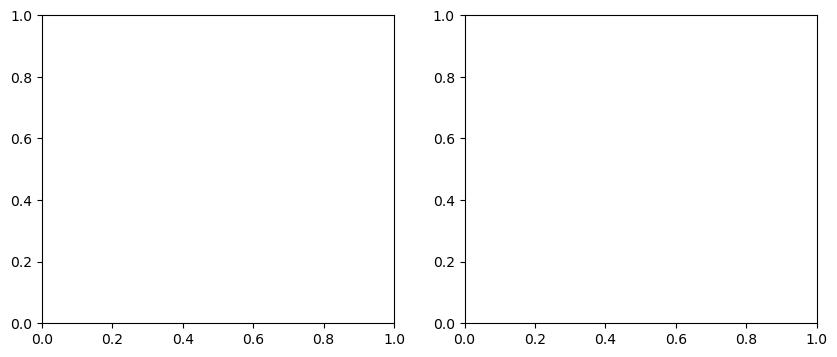

In [ ]:
# Plot a simple comparison of F1 scores and training time
fig, ax = plt.subplots(1,2, figsize=(10,4))
sns.barplot(x='model', y='f1', data=results, ax=ax[0])
ax[0].set_title('F1 score comparison')
sns.barplot(x='model', y='train_time_s', data=results, ax=ax[1])
ax[1].set_title('Training time (s)')
plt.tight_layout()
plt.show()

In [ ]:
# Learning curve for Random Forest (training vs validation)
train_sizes, train_scores, test_scores = learning_curve(rf, X_train_processed.fillna(0), y_train, cv=5, scoring='f1', n_jobs=-1, train_sizes=np.linspace(0.1,1.0,5))
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
plt.figure(figsize=(6,4))
plt.plot(train_sizes, train_scores_mean, 'o-', label='Training score')
plt.plot(train_sizes, test_scores_mean, 'o-', label='Validation score')
plt.xlabel('Training examples')
plt.ylabel('F1 score')
plt.title('Learning Curve — Random Forest')
plt.legend()
plt.show()

NameError: name 'X_train_processed' is not defined

## Reflection and next steps

**Feature engineering plans:** Add interaction terms across more features, create domain-specific aggregates, and test polynomial features. Aim for 5+ engineered features in the final submission.

**Model optimization plans:** Run hyperparameter tuning (GridSearchCV or RandomizedSearchCV), try tree-based boosting (XGBoost/LightGBM), and consider resampling or class-weighting if class imbalance is present.

**Questions for instructor:** Is stratified splitting acceptable for this problem? Are there domain constraints on feature creation or transformations to avoid?